In [1]:
%matplotlib inline
#
import sys; sys.path.insert(0, "..")
from multifunbrain import *
import pickle as pk
#
from nilearn import datasets, plotting, image
from nilearn.datasets import load_mni152_template
import xml.etree.ElementTree as ET
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap
from scipy.linalg import eigh
#
if Path.cwd().name != 'multifun-brain':
    path_root = Path.cwd().parent
    os.chdir(path_root)
path_data =  path_root / Path("data")
path_corrmat = path_data / 'correlation_matrices'
path_imf_matrices = path_corrmat / 'bold_matrices_from_IMF'
#

### Set the atlas

In [2]:
# Fetch the Harvard-Oxford cortical atlas.
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-2mm', data_dir=path_data)
atlas_filename = atlas.maps
atlas_img = image.load_img(atlas_filename)
atlas_data = atlas_img.get_fdata()
#
rois = atlas.labels
rois_label_map = {i: ll for i,ll in enumerate(rois[1:])}
roi_indices = np.unique(list(rois_label_map.keys()))
# Load MNI152 template for the background.
template = load_mni152_template()

[get_dataset_dir] Dataset found in /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/fsl


### Load matrix

In [41]:
fnames = os.listdir(path_imf_matrices)
for i in range(len(fnames)):
    print(fnames[i])

S5_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
S5_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
S5S4Special_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
S5S4_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
S5S4Special_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
S5S4_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl


In [42]:
path_fname = path_imf_matrices / fnames[2]
with open(path_fname, 'rb') as f:
    bold_matrix_test = pk.load(f)

In [43]:
# Replace NaN values with 0
bold_matrix_test_no_nan = np.nan_to_num(bold_matrix_test, nan=0.0)
bold_matrix_test_clean = (bold_matrix_test_no_nan + bold_matrix_test_no_nan.T) / 2
# Set diagonal to 0
# np.fill_diagonal(bold_matrix_test_clean, 0.0)
eigvals_C = np.linalg.eigvals(bold_matrix_test_clean)

In [44]:
n_channels, time_steps = 48, 488
gamma = time_steps/n_channels
lambda_min = (1 - np.sqrt(1/gamma))**2
lambda_max = (1 + np.sqrt(1/gamma))**2
#
counts, bins = np.histogram(eigvals_C, density=True, bins=500)
x_theory = np.linspace(max(0, lambda_min-0.1), lambda_max+0.1, 1000)
mp_theory = marchenko_pastur_density(x_theory, gamma, 1)

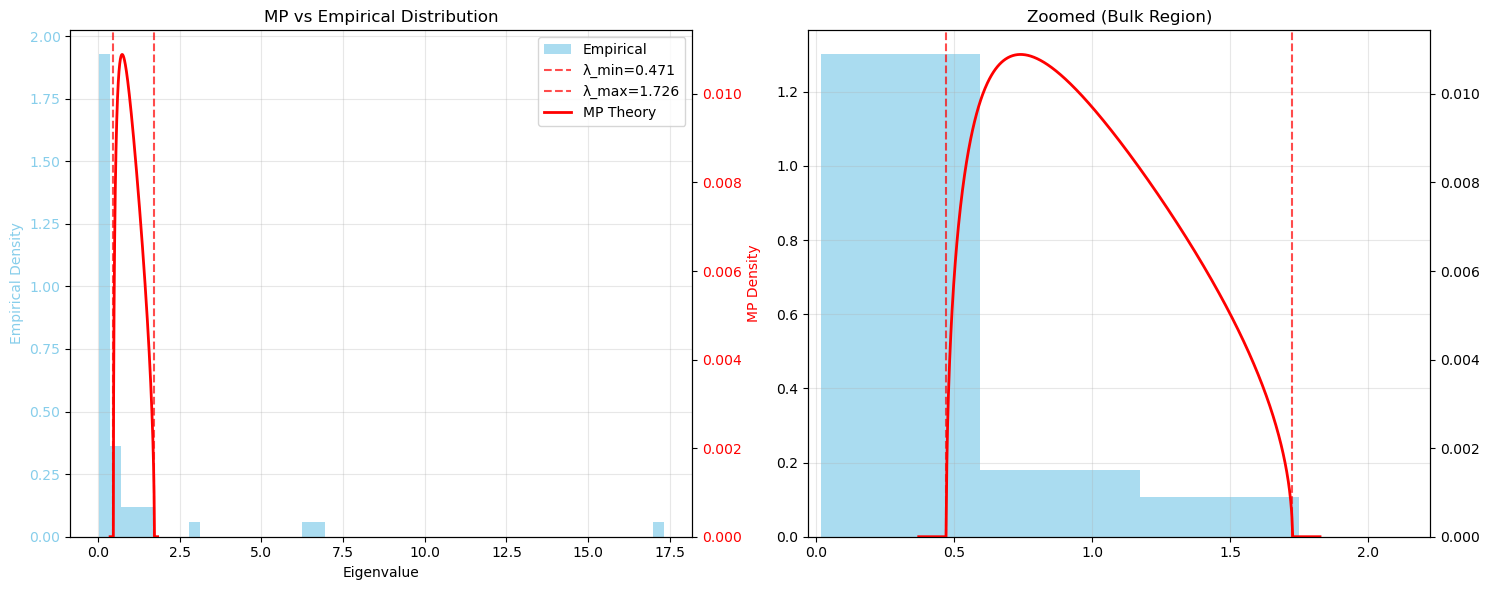

Matrix: (48, 48), γ=10.17, MP bounds=[0.471, 1.726]
Eigenvalues outside MP bounds: 38/48


In [45]:
# Marchenko-Pastur vs Empirical Eigenvalue Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Theory curve
x_theory = np.linspace(max(0, lambda_min-0.1), lambda_max+0.1, 1000)
mp_theory = marchenko_pastur_density(x_theory, gamma)

# Left: Full comparison with twin y-axes
ax1.hist(eigvals_C, bins=50, density=True, alpha=0.7, color='skyblue', label='Empirical')
ax1.set_xlabel('Eigenvalue')
ax1.set_ylabel('Empirical Density', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax1_twin = ax1.twinx()
ax1_twin.plot(x_theory, mp_theory, 'r-', linewidth=2, label='MP Theory')
ax1_twin.set_ylabel('MP Density', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')

# Align zeros
ax1.set_ylim(0, ax1.get_ylim()[1])
ax1_twin.set_ylim(0, ax1_twin.get_ylim()[1])

ax1.axvline(lambda_min, color='red', linestyle='--', alpha=0.7, label=f'λ_min={lambda_min:.3f}')
ax1.axvline(lambda_max, color='red', linestyle='--', alpha=0.7, label=f'λ_max={lambda_max:.3f}')
ax1.set_title('MP vs Empirical Distribution')
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Right: Zoomed view
bulk_min, bulk_max = lambda_min - 0.5, lambda_max + 0.5
ax2.hist(eigvals_C, bins=30, density=True, alpha=0.7, color='skyblue')
ax2.set_xlim(bulk_min, bulk_max)
ax2_twin = ax2.twinx()
ax2_twin.plot(x_theory, mp_theory, 'r-', linewidth=2)
ax2.set_ylim(0, ax2.get_ylim()[1])
ax2_twin.set_ylim(0, ax2_twin.get_ylim()[1])
ax2.axvline(lambda_min, color='red', linestyle='--', alpha=0.7)
ax2.axvline(lambda_max, color='red', linestyle='--', alpha=0.7)
ax2.set_title('Zoomed (Bulk Region)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Matrix: {bold_matrix_test_clean.shape}, γ={gamma:.2f}, MP bounds=[{lambda_min:.3f}, {lambda_max:.3f}]")
print(f"Eigenvalues outside MP bounds: {np.sum((eigvals_C < lambda_min) | (eigvals_C > lambda_max))}/48")

In [46]:
# MP-based correlation matrix cleaning
evals_orig, evecs_orig = np.linalg.eigh(bold_matrix_test_clean)
sort_idx = np.argsort(evals_orig)[::-1]
evals_orig, evecs_orig = evals_orig[sort_idx], evecs_orig[:, sort_idx]

# Identify signal vs noise eigenvectors based on MP bounds
signal_mask = (evals_orig < lambda_min) | (evals_orig > lambda_max)
n_signal, n_noise = np.sum(signal_mask), np.sum(~signal_mask)

# Project onto signal subspace and convert back to correlation matrix
signal_projector = evecs_orig[:, signal_mask] @ evecs_orig[:, signal_mask].T
bold_matrix_signal_proj = signal_projector @ bold_matrix_test_clean @ signal_projector

# Normalize to correlation form (cov2corr transformation)
diag_elements = np.diag(bold_matrix_signal_proj).copy()
diag_elements[diag_elements <= 0] = 1e-10
D_inv = np.diag(1.0 / np.sqrt(diag_elements))
bold_matrix_mp_cleaned = D_inv @ bold_matrix_signal_proj @ D_inv

# Ensure valid correlation matrix
bold_matrix_mp_cleaned = (bold_matrix_mp_cleaned + bold_matrix_mp_cleaned.T) / 2
np.fill_diagonal(bold_matrix_mp_cleaned, 1.0)

# Verify cleaning results
eigvals_clean = np.sort(np.linalg.eigvals(bold_matrix_mp_cleaned))[::-1]
in_mp = np.sum((eigvals_clean >= lambda_min) & (eigvals_clean <= lambda_max))

print(f"MP Cleaning: {n_noise}→{in_mp} eigenvalues in noise range (removed {n_noise-in_mp})")
print(f"Signal eigenvectors preserved: {n_signal}, Matrix valid: {np.allclose(np.diag(bold_matrix_mp_cleaned), 1.0)}")

MP Cleaning: 10→3 eigenvalues in noise range (removed 7)
Signal eigenvectors preserved: 38, Matrix valid: True


/home/opisthofulax/anaconda3/envs/multifun-brain/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/opisthofulax/anaconda3/envs/multifun-brain/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


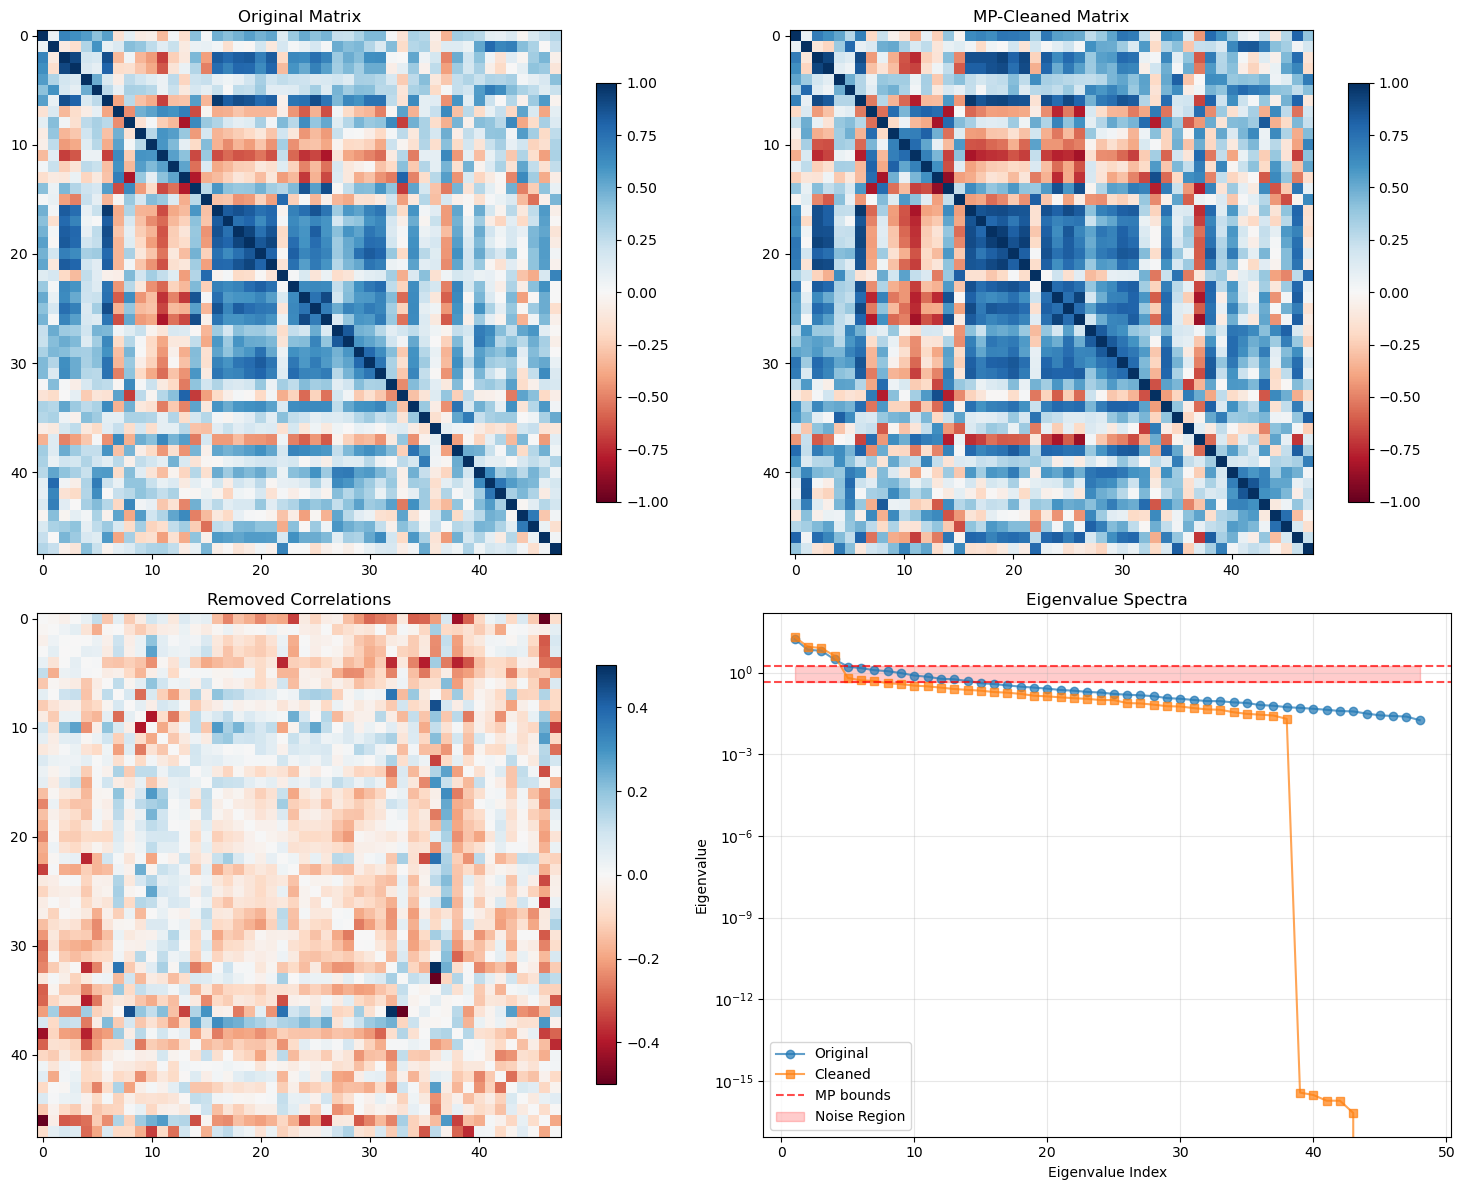

Original: 0.332±0.224 |correlation|
Cleaned:  0.420±0.256 |correlation|
Removed:  0.097±0.083 |correlation|


In [47]:
# Matrix comparison visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Original vs cleaned matrices
im1 = ax1.imshow(bold_matrix_test_clean, cmap='RdBu', vmin=-1, vmax=1)
ax1.set_title('Original Matrix')
plt.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(bold_matrix_mp_cleaned, cmap='RdBu', vmin=-1, vmax=1)
ax2.set_title('MP-Cleaned Matrix')
plt.colorbar(im2, ax=ax2, shrink=0.8)

# Difference (removed correlations)
difference_matrix = bold_matrix_test_clean - bold_matrix_mp_cleaned
im3 = ax3.imshow(difference_matrix, cmap='RdBu', vmin=-0.5, vmax=0.5)
ax3.set_title('Removed Correlations')
plt.colorbar(im3, ax=ax3, shrink=0.8)

# Eigenvalue comparison
eigvals_orig = np.sort(np.linalg.eigvals(bold_matrix_test_clean))[::-1]
eigvals_clean = np.sort(np.linalg.eigvals(bold_matrix_mp_cleaned))[::-1]

ax4.plot(range(1, len(eigvals_orig)+1), eigvals_orig, 'o-', label='Original', alpha=0.7)
ax4.plot(range(1, len(eigvals_clean)+1), eigvals_clean, 's-', label='Cleaned', alpha=0.7)
ax4.axhline(lambda_min, color='red', linestyle='--', alpha=0.7, label=f'MP bounds')
ax4.axhline(lambda_max, color='red', linestyle='--', alpha=0.7)
ax4.fill_between(range(1, 49), lambda_min, lambda_max, alpha=0.2, color='red', label='Noise Region')
ax4.set_xlabel('Eigenvalue Index')
ax4.set_ylabel('Eigenvalue')
ax4.set_title('Eigenvalue Spectra')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

# Compact summary
orig_corr = np.abs(bold_matrix_test_clean[np.triu_indices_from(bold_matrix_test_clean, k=1)])
clean_corr = np.abs(bold_matrix_mp_cleaned[np.triu_indices_from(bold_matrix_mp_cleaned, k=1)])
removed_corr = np.abs(difference_matrix[np.triu_indices_from(difference_matrix, k=1)])

print(f"Original: {orig_corr.mean():.3f}±{orig_corr.std():.3f} |correlation|")
print(f"Cleaned:  {clean_corr.mean():.3f}±{clean_corr.std():.3f} |correlation|") 
print(f"Removed:  {removed_corr.mean():.3f}±{removed_corr.std():.3f} |correlation|")

In [48]:
G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(bold_matrix_mp_cleaned))
G = nx.convert_node_labels_to_integers(G)
#
A = nx.to_numpy_array(G)
D = np.diag(np.sum(np.abs(A), axis=1))
L = D - A
eigvals, eigvecs = eigh(L)
# pos_spectral = {i: eigvecs[i, 1:3] for i in range(A.shape[0])}
#

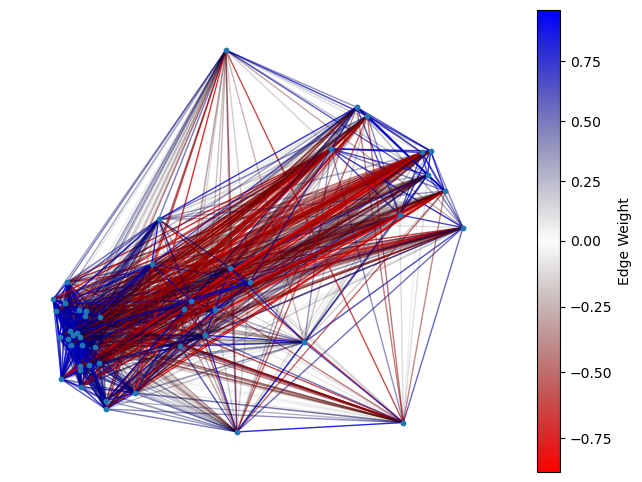

In [79]:
fig, ax = plt.subplots(figsize=(8,6))
edge_weights = [G[u][v].get('weight', 0) for u, v in G.edges()]
norm = TwoSlopeNorm(vmin=min(edge_weights), vcenter=0, vmax=max(edge_weights))
cmap = LinearSegmentedColormap.from_list(
    'red_transparent_blue',
    [(0.0, (1, 0, 0, 1)),      # Red, opaque
     (0.5, (0, 0, 0, .01)),      # Transparent (white, alpha=0)
     (1.0, (0, 0, 1, 1))],     # Blue, opaque
    N=256
)
edge_colors = [cmap(norm(w)) for w in edge_weights]
# Draw the graph with colored edges
nx.draw(G, ax=ax, edge_color=edge_colors, node_size=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(edge_weights)
plt.colorbar(sm, ax=ax, label='Edge Weight')
plt.show()

In [86]:
A_old = nx.to_numpy_array(G)
A_new = np.abs(A_old)#np.where(A_old < 0, 0, A_old)
G_pos = nx.from_numpy_array(A_new)
Th, Einf, Pinf = compute_threshold_stats_fast(G_pos)
Th, jump = find_threshold_jumps(G_pos)

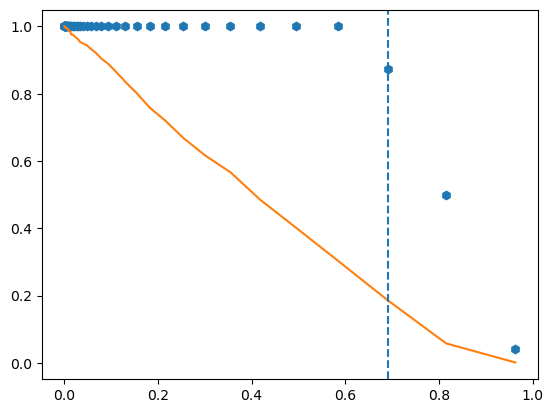

In [105]:
sel_thresh = Th[jump[1]]
plt.plot(Th, Pinf, 'h')
plt.plot(Th, Einf)
plt.axvline(sel_thresh, ls='--')

In [106]:
A_prime = nx.to_numpy_array(G_pos)
A_thresh = np.where(A_prime < sel_thresh, 0, A_prime)
G_pos, lost_nodes_1 = get_giant_component_leftoff(nx.from_numpy_array(A_thresh))

In [107]:
A_old.shape, A_prime.shape, A_new.shape, A_thresh.shape

((48, 48), (48, 48), (48, 48), (48, 48))

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/notebooks/../multifunbrain/lrglib.py:53: RuntimeWarning: divide by zero encountered in log
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)
/home/opisthofulax/Documents/UniPa/projects/multifun-brain/notebooks/../multifunbrain/lrglib.py:53: RuntimeWarning: invalid value encountered in multiply
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)


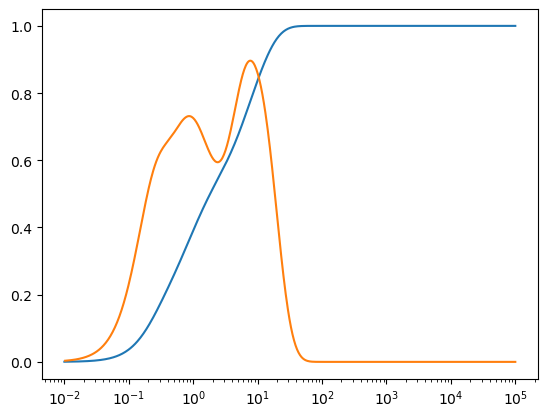

In [108]:
w = nx.laplacian_spectrum(G_pos)
Sm1, dS, VarL, tau  = entropy(w)
plt.plot(tau, Sm1)
plt.plot(tau[1:], dS)
plt.xscale('log')

In [109]:
L = nx.laplacian_matrix(G_pos).toarray()
rho_m = lambda tau: rho_matrix(tau, L)
dists = symmetrized_inverse_distance(0.1, rho_m)
linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
tmin = linkage_matrix[::, 2][0] - 0.5*linkage_matrix[::, 2][0]
threshold = 1e-1
optimal_clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')

(np.float64(1.5705871380745726e-10), np.float64(1.0396039603960394))

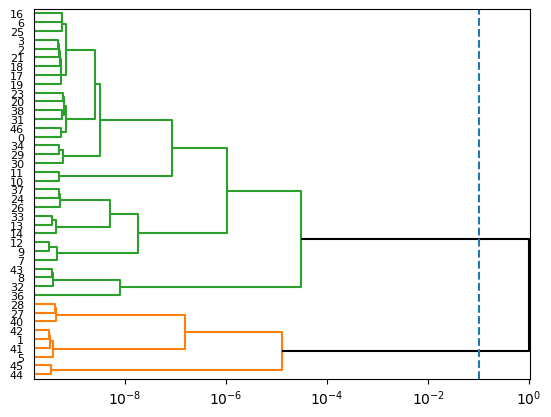

In [110]:
dendro = dendrogram(linkage_matrix, color_threshold=threshold,
                        above_threshold_color='k',
                        orientation='right', labels=label_list)
plt.xscale('log')
plt.axvline(x=threshold, ls='--')
plt.xlim(tmin)

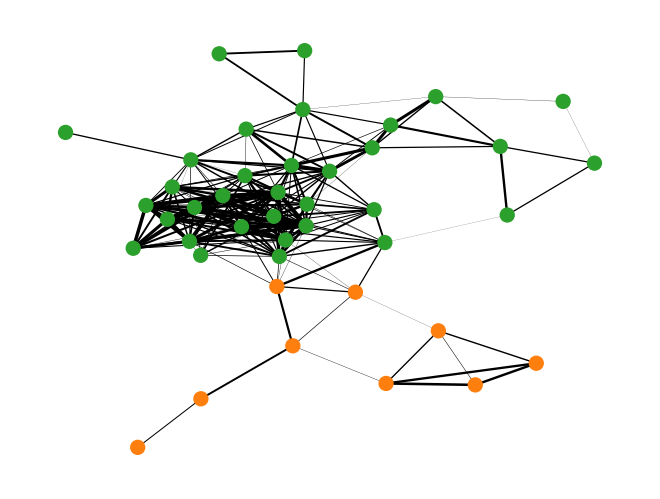

In [111]:
leaf_label_colors = {label: color for label, color in zip(dendro['ivl'], dendro['leaves_color_list'])}
node_colors = [leaf_label_colors[label] for _,label in enumerate(label_list)]
edge_weights = [G_pos[u][v].get('weight', 0) for u, v in G_pos.edges()]
min_w, max_w = min(edge_weights), max(edge_weights)
widths = [0.1 + (abs(w) - abs(min_w)) / (abs(max_w) - abs(min_w)) * (3 - 0.1) if max_w != min_w else 3 for w in edge_weights]
pos = nx.kamada_kawai_layout(G_pos)
nx.draw(G_pos, pos=pos, width=widths, node_size=100, node_color=node_colors)

In [63]:
indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
node_colors_all = node_colors.copy()
for idx in reversed(indices_to_insert):
    node_colors_all.insert(idx, 'white')
cmap = ListedColormap(node_colors_all)

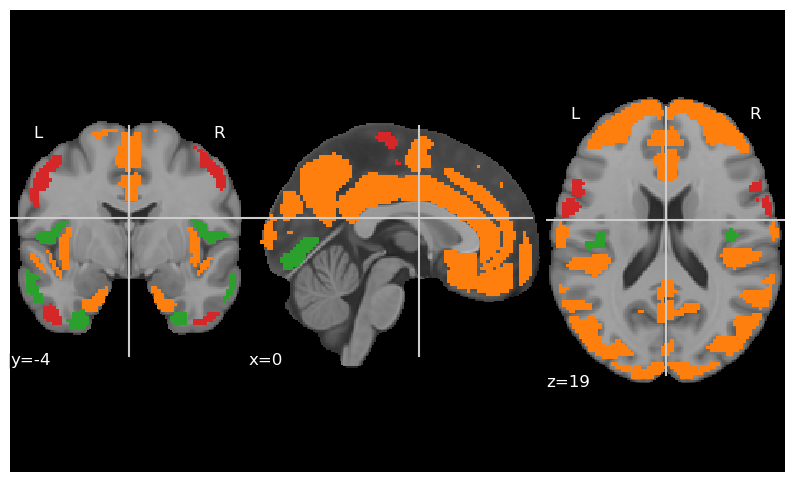

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
# Plot the atlas regions on the anatomical background.
plotting.plot_stat_map(atlas_img, bg_img=template, axes=ax, cmap=cmap, colorbar=False)
plotting.show()